# CommerceLens — Layer 2: Insight → Action

**Anchor question:** *Where is revenue concentrated, and which operational factors (delivery time, freight cost, product category, region) drive customer satisfaction and repeat purchases?*

Layer 1 showed **where** revenue sits. This layer tests **which operational factors move satisfaction and retention**, and ends with a *Findings & Recommendations* section in which every number is a variable computed in this notebook.

| Query file | Question |
|---|---|
| `11_delay_vs_review.sql`, `12_late_vs_ontime.sql` | How much does late delivery cost in review score? |
| `14_state_ops.sql` | Which regions are late, and does it show in reviews? |
| `13_category_ops.sql` | Which categories combine high revenue with poor experience? |
| `15_freight_ratio_vs_review.sql` | Does a high freight charge hurt satisfaction on its own? |
| `17_seller_tier_ops.sql` | Do the top sellers (82% of revenue) deliver worse or better? |
| `16_first_order_vs_repeat.sql` | Does a bad first order stop customers coming back? |

**Definitions:** *Late* = delivered after `order_estimated_delivery_date`. *Low review* = score 1–2. Scope = delivered orders with a delivery date and a review.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

from src import db

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8983"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pct = mtick.PercentFormatter(decimals=0)

con = db.connect()

## 1. Delivery delay vs review score

`delay_days` = actual − estimated delivery date (negative = early).

,bucket_order,delay_bucket,orders,pct_of_orders,avg_review,pct_low_review,pct_five_star
0,1,15+ days early,34771,36.29,4.32,9.04,64.28
1,2,8-14 days early,36158,37.73,4.31,8.91,63.02
2,3,1-7 days early,17234,17.99,4.20,10.24,57.49
3,4,On estimated day,1280,1.34,4.03,12.42,50.63
4,5,1-3 days late,1852,1.93,3.29,32.13,33.15
5,6,4-7 days late,1748,1.82,2.10,67.68,14.07
6,7,8-14 days late,1446,1.51,1.67,80.15,6.85
7,8,15+ days late,1335,1.39,1.72,78.35,7.19


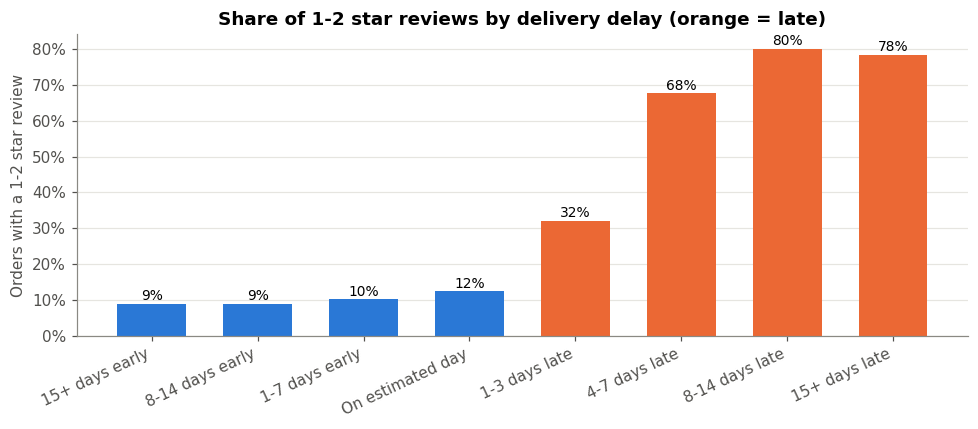

In [2]:
delay = db.query(con, "11_delay_vs_review.sql")
display(delay)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ORANGE if "late" in b else BLUE for b in delay["delay_bucket"]]
ax.bar(delay["delay_bucket"], delay["pct_low_review"], color=colors, width=0.65)
for x, v in enumerate(delay["pct_low_review"]):
    ax.text(x, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("Orders with a 1-2 star review")
ax.grid(axis="x", visible=False)
plt.xticks(rotation=25, ha="right")
ax.set_title("Share of 1-2 star reviews by delivery delay (orange = late)")
plt.tight_layout(); plt.show()

In [3]:
late_vs = db.query(con, "12_late_vs_ontime.sql").set_index("delivery")
display(late_vs)

late, ontime = late_vs.loc["Late"], late_vs.loc["On time or early"]
late_share = late.pct_of_orders
low_late, low_ontime = late.pct_low_review, ontime.pct_low_review
low_ratio = low_late / low_ontime

n_low_late = late.orders * low_late / 100
n_low_ontime = ontime.orders * low_ontime / 100
share_low_from_late = 100 * n_low_late / (n_low_late + n_low_ontime)
# Upper-bound counterfactual: late orders reviewed like on-time orders.
avoidable_low = late.orders * (low_late - low_ontime) / 100
avoidable_pct = 100 * avoidable_low / (n_low_late + n_low_ontime)
overall_low = 100 * (n_low_late + n_low_ontime) / (late.orders + ontime.orders)

on_day = delay.set_index("delay_bucket").loc["On estimated day", "pct_low_review"]
early_pct = delay.loc[delay["bucket_order"] <= 3, "pct_of_orders"].sum()
late_1_3 = delay.set_index("delay_bucket").loc["1-3 days late", "pct_low_review"]

print(f"Late orders: {late_share:.1f}% of orders, {low_late:.1f}% low reviews vs {low_ontime:.1f}% on time ({low_ratio:.1f}x).")
print(f"Late orders generate {share_low_from_late:.1f}% of all 1-2 star reviews.")
print(f"Upper bound: ~{avoidable_low:,.0f} low reviews ({avoidable_pct:.1f}% of all) would not happen if late orders were reviewed like on-time ones.")
print(f"{early_pct:.1f}% of orders arrive early; even 1-3 days late already gives {late_1_3:.1f}% low reviews.")

,orders,pct_of_orders,avg_review,pct_low_review,pct_five_star,avg_delivery_days
delivery,,,,,,
Late,6381,6.66,2.27,62.42,16.53,33.80
On time or early,89443,93.34,4.29,9.27,62.27,10.90


Late orders: 6.7% of orders, 62.4% low reviews vs 9.3% on time (6.7x).
Late orders generate 32.4% of all 1-2 star reviews.
Upper bound: ~3,392 low reviews (27.6% of all) would not happen if late orders were reviewed like on-time ones.
92.0% of orders arrive early; even 1-3 days late already gives 32.1% low reviews.


## 2. Region: where are deliveries late?

In [4]:
states = db.query(con, "14_state_ops.sql")
display(states)

sp = states.set_index("customer_state").loc["SP"]
rj = states.set_index("customer_state").loc["RJ"]
rj_rev_share = 100 * rj.revenue / states["revenue"].sum()
national_late = np.average(states["late_pct"], weights=states["orders"])
hot_states = states[(states["late_pct"] >= 2 * national_late) & (states["orders"] >= 300)]
hot_rev_share = 100 * hot_states["revenue"].sum() / states["revenue"].sum()

# Order-weighted correlation across states between late rate and low-review rate.
w = states["orders"]
def wcorr(x, y, w):
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    return np.average((x - mx) * (y - my), weights=w) / np.sqrt(np.average((x - mx) ** 2, weights=w) * np.average((y - my) ** 2, weights=w))
state_corr = wcorr(states["late_pct"], states["pct_low_review"], w)

print(f"RJ: {rj_rev_share:.1f}% of revenue, late rate {rj.late_pct:.1f}% vs SP {sp.late_pct:.1f}% ({rj.late_pct/sp.late_pct:.1f}x); "
      f"low reviews {rj.pct_low_review:.1f}% vs {sp.pct_low_review:.1f}%.")
print(f"National late rate {national_late:.1f}%. States at >= 2x with 300+ orders: {', '.join(hot_states['customer_state'])} "
      f"({hot_rev_share:.1f}% of revenue).")
print(f"Order-weighted correlation (state late % vs low-review %): r = {state_corr:.2f}")

,customer_state,orders,revenue,avg_delivery_days,late_pct,freight_pct_of_price,avg_review,pct_low_review
0,SP,40494,"5,066,562.98",8.70,4.49,13.85,4.25,10.69
1,RJ,12350,"1,759,651.13",15.20,12.11,16.81,3.96,18.33
2,MG,11354,"1,552,481.83",11.90,4.57,17.16,4.19,11.75
3,RS,5344,"728,718.47",15.20,6.08,18.19,4.18,11.92
4,PR,4923,"666,063.51",11.90,4.04,17.36,4.24,10.88
5,SC,3546,"507,012.13",14.90,8.21,17.38,4.13,12.99
6,BA,3256,"493,584.14",19.30,12.16,19.76,3.93,17.00
7,DF,2080,"296,498.41",12.90,5.67,16.74,4.13,13.24
8,GO,1957,"282,836.70",15.50,6.54,18.16,4.11,13.16
9,ES,1995,"268,643.45",15.70,10.73,18.25,4.08,13.81


RJ: 13.3% of revenue, late rate 12.1% vs SP 4.5% (2.7x); low reviews 18.3% vs 10.7%.
National late rate 6.8%. States at >= 2x with 300+ orders: CE, MA, PI, AL, SE (4.2% of revenue).
Order-weighted correlation (state late % vs low-review %): r = 0.95


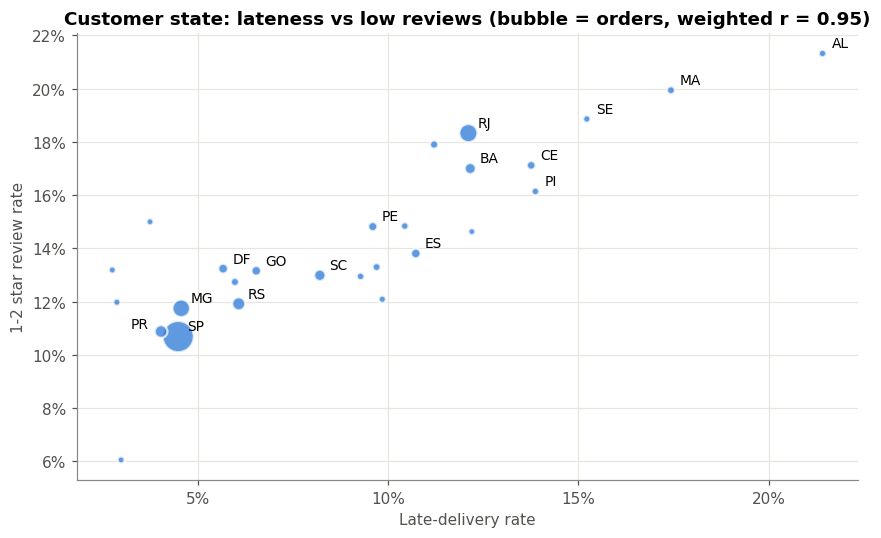

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = 20 + 400 * states["orders"] / states["orders"].max()
ax.scatter(states["late_pct"], states["pct_low_review"], s=sizes, color=BLUE, alpha=0.75, edgecolor="white", linewidth=1.5)
for _, r in states.iterrows():
    if r.orders >= 1500 or r.late_pct >= 2 * national_late:
        offset = (-20, 2) if r.customer_state == "PR" else (6, 4)  # avoid overlapping SP
        ax.annotate(r.customer_state, (r.late_pct, r.pct_low_review), xytext=offset, textcoords="offset points", fontsize=9)
ax.xaxis.set_major_locator(mtick.MultipleLocator(5))
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Late-delivery rate"); ax.set_ylabel("1-2 star review rate")
ax.set_title(f"Customer state: lateness vs low reviews (bubble = orders, weighted r = {state_corr:.2f})")
plt.tight_layout(); plt.show()

## 3. Category: high revenue, poor experience

In [6]:
cats = db.query(con, "13_category_ops.sql")
display(cats.head(20))

big = cats[cats["pct_of_revenue"] >= 1.0]
worst = big.sort_values("pct_low_review", ascending=False).iloc[0]
top5 = cats.head(5)
top5_above = top5[top5["pct_low_review"] > overall_low]
print(f"Overall low-review rate: {overall_low:.1f}%")
print(f"Worst category with >= 1% of revenue: {worst.category} - {worst.pct_low_review:.1f}% low reviews, "
      f"{worst.avg_delivery_days:.1f} avg delivery days, freight {worst.freight_pct_of_price:.1f}% of price.")
print("Top-5 revenue categories above the overall low-review rate: "
      + ", ".join(f"{r.category} ({r.pct_low_review:.1f}%, {r.pct_of_revenue:.1f}% of revenue)" for r in top5_above.itertuples()))

,category,orders,revenue,pct_of_revenue,avg_item_price,freight_pct_of_price,late_pct,avg_delivery_days,avg_review,pct_low_review
0,health_beauty,8647,"1,233,131.72",10.10,130.28,14.51,7.51,12.00,4.23,11.45
1,watches_gifts,5495,"1,166,176.98",9.55,199.04,8.42,7.39,12.70,4.12,13.70
2,bed_bath_table,9272,"1,023,434.76",8.38,93.44,19.72,7.43,12.90,4.00,16.03
3,sports_leisure,7530,"954,852.55",7.82,113.25,17.11,6.57,12.20,4.23,11.38
4,computers_accessories,6530,"888,724.61",7.28,116.26,16.20,6.39,13.10,4.08,14.56
5,furniture_decor,6307,"711,927.69",5.83,87.25,23.65,7.12,13.00,4.06,15.35
6,housewares,5743,"615,628.69",5.04,90.60,23.19,5.36,11.00,4.19,11.82
7,cool_stuff,3559,"610,204.10",5.00,164.12,13.35,5.90,12.30,4.22,11.27
8,auto,3810,"578,966.65",4.74,139.85,15.63,7.30,12.30,4.14,13.00
9,toys,3804,"471,286.48",3.86,116.94,16.08,6.39,11.70,4.24,11.39


Overall low-review rate: 12.8%
Worst category with >= 1% of revenue: office_furniture - 21.9% low reviews, 20.6 avg delivery days, freight 25.0% of price.
Top-5 revenue categories above the overall low-review rate: watches_gifts (13.7%, 9.6% of revenue), bed_bath_table (16.0%, 8.4% of revenue), computers_accessories (14.6%, 7.3% of revenue)


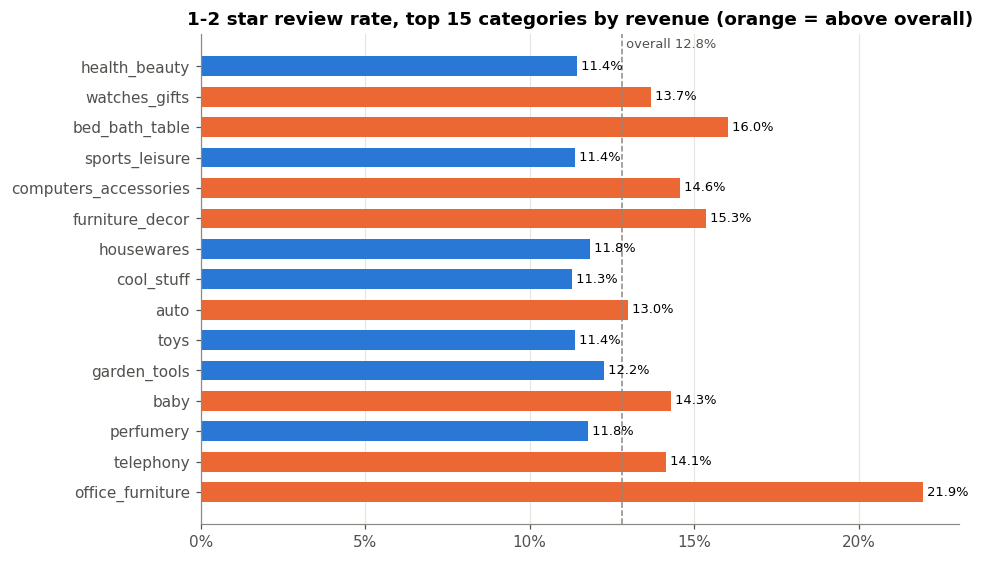

In [7]:
t = cats.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = [ORANGE if v > overall_low else BLUE for v in t["pct_low_review"]]
ax.barh(t["category"], t["pct_low_review"], color=colors, height=0.65)
ax.axvline(overall_low, color=GREY, ls="--", lw=1)
ax.text(overall_low, len(t) - 0.4, f" overall {overall_low:.1f}%", fontsize=8.5, color="#52514e")
for y, v in enumerate(t["pct_low_review"]):
    ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("1-2 star review rate, top 15 categories by revenue (orange = above overall)")
plt.tight_layout(); plt.show()

## 4. Freight cost

Two questions: (a) where is freight a heavy share of price, and (b) does a high freight share hurt reviews **on its own**? High-freight orders also travel further and arrive late more often, so (b) is checked on on-time orders only.

In [8]:
fr = cats.sort_values("freight_pct_of_price", ascending=False)
display(fr[["category", "pct_of_revenue", "avg_item_price", "freight_pct_of_price", "pct_low_review"]].head(10))

freight = db.query(con, "15_freight_ratio_vs_review.sql")
display(freight)

fr_lo, fr_hi = freight.iloc[0], freight.iloc[-1]
fr_corr = stats.spearmanr(cats["freight_pct_of_price"], cats["pct_low_review"])
top_fr = fr.iloc[0]
print(f"Highest freight burden: {top_fr.category} at {top_fr.freight_pct_of_price:.1f}% of price (avg item R${top_fr.avg_item_price:.0f}).")
print(f"On-time orders only: low-review rate {fr_lo.pct_low_review_on_time:.2f}% (freight <10% of price) -> "
      f"{fr_hi.pct_low_review_on_time:.2f}% (freight 50%+), a {fr_hi.pct_low_review_on_time - fr_lo.pct_low_review_on_time:.2f} pt gap.")
print(f"Same comparison for lateness: {low_ontime:.1f}% -> {low_late:.1f}%, a {low_late - low_ontime:.1f} pt gap.")
print(f"Category-level Spearman (freight % vs low-review %): rho = {fr_corr.statistic:.2f}, p = {fr_corr.pvalue:.3f}")

,category,pct_of_revenue,avg_item_price,freight_pct_of_price,pct_low_review
20,electronics,1.27,56.81,29.46,13.21
27,furniture_living_room,0.55,136.06,26.27,14.18
14,office_furniture,2.20,160.76,25.01,21.95
31,food,0.24,57.58,24.58,10.07
5,furniture_decor,5.83,87.25,23.65,15.35
6,housewares,5.04,90.60,23.19,11.82
13,telephony,2.54,69.95,22.38,14.13
24,luggage_accessories,1.14,128.79,21.68,8.18
10,garden_tools,3.85,110.24,20.54,12.25
21,fashion_bags_accessories,1.22,75.23,20.46,10.16


,bucket_order,freight_share_of_price,orders,avg_review,pct_low_review,late_pct,pct_low_review_on_time
0,1,<10%,15145,4.21,12.43,6.77,8.75
1,2,10-20%,27487,4.18,12.28,6.40,8.96
2,3,20-35%,25905,4.15,12.89,6.60,9.33
3,4,35-50%,12105,4.13,13.29,6.72,9.81
4,5,50%+,15182,4.11,13.61,7.06,9.80


Highest freight burden: electronics at 29.5% of price (avg item R$57).
On-time orders only: low-review rate 8.75% (freight <10% of price) -> 9.80% (freight 50%+), a 1.05 pt gap.
Same comparison for lateness: 9.3% -> 62.4%, a 53.2 pt gap.
Category-level Spearman (freight % vs low-review %): rho = -0.04, p = 0.822


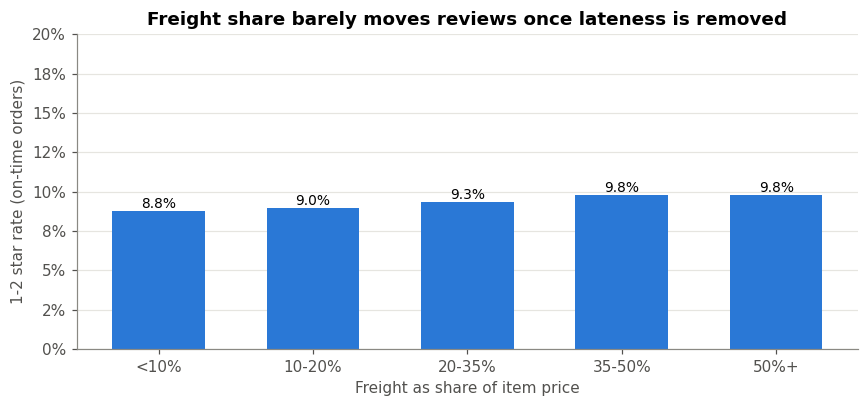

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(freight["freight_share_of_price"], freight["pct_low_review_on_time"], color=BLUE, width=0.6)
for x, v in enumerate(freight["pct_low_review_on_time"]):
    ax.text(x, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylim(0, max(20, freight["pct_low_review_on_time"].max() * 1.3))
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Freight as share of item price"); ax.set_ylabel("1-2 star rate (on-time orders)")
ax.grid(axis="x", visible=False)
ax.set_title("Freight share barely moves reviews once lateness is removed")
plt.tight_layout(); plt.show()

## 5. Seller concentration vs operational quality

In [10]:
tiers = db.query(con, "17_seller_tier_ops.sql").set_index("seller_tier")
display(tiers)
top_t, rest_t = tiers.loc["Top 20% sellers"], tiers.loc["Other 80% sellers"]
print(f"Top 20% sellers: {top_t.pct_of_revenue:.1f}% of revenue, late {top_t.late_pct:.2f}% vs {rest_t.late_pct:.2f}% for the rest; "
      f"low reviews {top_t.pct_low_review:.2f}% vs {rest_t.pct_low_review:.2f}%.")

,sellers,revenue,pct_of_revenue,orders,late_pct,avg_review,pct_low_review
seller_tier,,,,,,,
Top 20% sellers,594,"10,879,659.64",82.29,74283,6.79,4.13,13.21
Other 80% sellers,2376,"2,341,838.47",17.71,22646,6.59,4.20,12.15


Top 20% sellers: 82.3% of revenue, late 6.79% vs 6.59% for the rest; low reviews 13.21% vs 12.15%.


## 6. Does a bad first order stop customers coming back?

For each customer's **first** delivered order: did they buy again within 180 days? Only customers with a full 180-day window are included (right-censoring guard). Differences are tested with a two-proportion z-test / chi-square.

In [11]:
rep = db.query(con, "16_first_order_vs_repeat.sql")
display(rep)

def two_prop_z(x1, n1, x2, n2):
    """Two-sided two-proportion z-test; returns (z, p)."""
    p = (x1 + x2) / (n1 + n2)
    z = (x1 / n1 - x2 / n2) / np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    return z, 2 * stats.norm.sf(abs(z))

r = rep.set_index(["dimension", "value"])
rl, ro = r.loc[("First order delivery", "Late")], r.loc[("First order delivery", "On time or early")]
z_late, p_late = two_prop_z(rl.returned, rl.customers, ro.returned, ro.customers)

rv = rep[rep["dimension"] == "First order review"]
chi2, p_review, _, _ = stats.chi2_contingency(np.c_[rv["returned"], rv["customers"] - rv["returned"]])

sig = lambda p: "significant" if p < 0.05 else "not significant"
base_repeat = r.loc[("All eligible customers", "All"), "repeat_rate_180d_pct"]
print(f"180-day repeat rate overall: {base_repeat:.2f}% (n = {r.loc[('All eligible customers', 'All'), 'customers']:,.0f})")
print(f"Late first order: {rl.repeat_rate_180d_pct:.2f}% vs on time {ro.repeat_rate_180d_pct:.2f}% (z = {z_late:.2f}, p = {p_late:.3f})")
print(f"By first review score (1-2 / 3 / 4-5): chi2 = {chi2:.2f}, p = {p_review:.3f}")

,dimension,value,customers,returned,repeat_rate_180d_pct
0,All eligible customers,All,55907,"1,736.00",3.10
1,First order delivery,Late,3778,100.00,2.65
2,First order delivery,On time or early,52127,"1,636.00",3.14
3,First order review,1-2 (low),7358,228.00,3.10
4,First order review,3,4850,159.00,3.28
5,First order review,4-5 (high),43283,"1,338.00",3.09


180-day repeat rate overall: 3.10% (n = 55,907)
Late first order: 2.65% vs on time 3.14% (z = -1.68, p = 0.093)
By first review score (1-2 / 3 / 4-5): chi2 = 0.51, p = 0.775


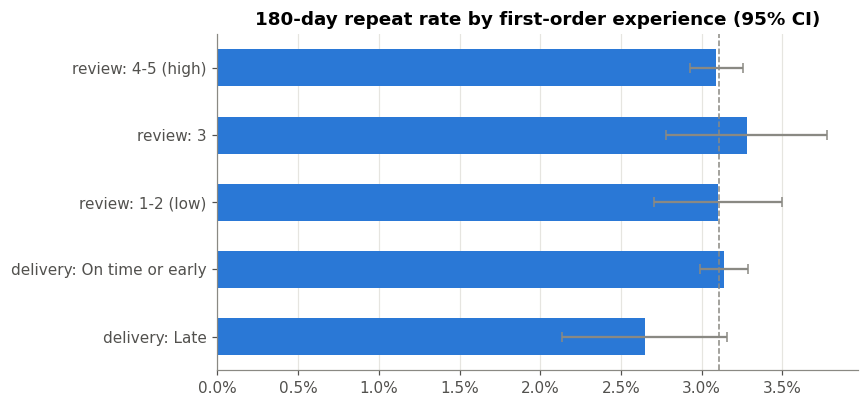

In [12]:
d = rep[rep["dimension"] != "All eligible customers"].copy()
p_hat = d["repeat_rate_180d_pct"] / 100
d["ci95"] = 100 * 1.96 * np.sqrt(p_hat * (1 - p_hat) / d["customers"])
labels = d["dimension"].str.replace("First order ", "") + ": " + d["value"]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(labels, d["repeat_rate_180d_pct"], xerr=d["ci95"], color=BLUE, height=0.55, error_kw=dict(ecolor=GREY, capsize=3))
ax.axvline(base_repeat, color=GREY, ls="--", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.grid(axis="y", visible=False)
ax.set_title("180-day repeat rate by first-order experience (95% CI)")
plt.tight_layout(); plt.show()

## 7. Findings & Recommendations

Each row runs **problem → finding → so-what → recommended action**, and every figure is an f-string over a variable computed above. Layer 1 numbers are re-derived here from the same SQL, so this notebook stands on its own.

In [13]:
# Layer 1 context, recomputed from the same SQL files.
kpis = db.query(con, "10_kpis.sql").iloc[0]
db.run_script(con, "08_rfm_customers.sql")
seg = db.query(con, "09_rfm_segments.sql").set_index("segment")
at_risk = seg.loc["At risk, high value"]
freq = db.query(con, "07_order_frequency.sql")
one_time = freq.loc[freq["orders_per_customer"] == "1", "pct_of_customers"].iloc[0]

findings = [
    dict(
        problem="Which operational factor hurts satisfaction most?",
        finding=f"Late orders are {late_share:.1f}% of orders but get 1-2 star reviews {low_late:.1f}% of the time vs {low_ontime:.1f}% on time ({low_ratio:.1f}x); "
                f"they produce {share_low_from_late:.1f}% of all low reviews. Even 1-3 days late gives {late_1_3:.1f}%.",
        so_what=f"Lateness is the single biggest lever on ratings: up to ~{avoidable_low:,.0f} low reviews ({avoidable_pct:.1f}% of all) are attributable to it (upper bound).",
        action="Treat on-time delivery as the #1 satisfaction KPI: flag at-risk orders before the estimated date (see the Layer 3 model), notify customers proactively, and put carrier SLAs on the late tail.",
    ),
    dict(
        problem="Is lateness a regional problem?",
        finding=f"RJ is {rj_rev_share:.1f}% of revenue with a {rj.late_pct:.1f}% late rate vs {sp.late_pct:.1f}% in SP ({rj.late_pct/sp.late_pct:.1f}x) and {rj.pct_low_review:.1f}% low reviews vs {sp.pct_low_review:.1f}%. "
                f"States at >= 2x the national late rate ({national_late:.1f}%): {', '.join(hot_states['customer_state'])} ({hot_rev_share:.1f}% of revenue). State late rate vs low-review rate: weighted r = {state_corr:.2f}.",
        so_what="Lateness is concentrated in specific lanes, with RJ the one with real revenue at stake. A regional fix is more efficient than a platform-wide one.",
        action="Audit carriers and estimated-date logic on SP->RJ and North-East lanes first; widen the promised date where the lane cannot be fixed, since reviews react to the gap vs the promise.",
    ),
    dict(
        problem="Which categories combine revenue with poor experience?",
        finding=f"{worst.category} ({worst.pct_of_revenue:.1f}% of revenue) has the worst low-review rate among categories with >= 1% revenue: {worst.pct_low_review:.1f}% vs {overall_low:.1f}% overall, "
                f"with {worst.avg_delivery_days:.1f} avg delivery days. Top-5 revenue categories above the overall rate: "
                + (", ".join(f"{r.category} ({r.pct_low_review:.1f}%)" for r in top5_above.itertuples()) or "none") + ".",
        so_what="Bulky or slow-shipping categories carry a satisfaction penalty that the category mix hides in the average.",
        action=f"Set category-specific delivery promises and seller packaging/handling standards for {worst.category}; watch the top-revenue categories above the line in a monthly quality review.",
    ),
    dict(
        problem="Does freight cost drive dissatisfaction?",
        finding=f"On on-time orders, the low-review rate only moves from {fr_lo.pct_low_review_on_time:.2f}% to {fr_hi.pct_low_review_on_time:.2f}% as freight goes from <10% to 50%+ of price "
                f"({fr_hi.pct_low_review_on_time - fr_lo.pct_low_review_on_time:.2f} pt), vs a {low_late - low_ontime:.1f} pt gap for lateness. "
                f"{top_fr.category} carries the highest freight burden ({top_fr.freight_pct_of_price:.1f}% of price).",
        so_what="Freight price is a weak satisfaction driver once delivery is on time. Subsidising shipping would buy little rating improvement.",
        action="Do not fund freight subsidies to fix reviews; spend on delivery reliability instead. Test free-shipping thresholds as a conversion lever for high-freight, low-price categories (needs funnel data this dataset lacks).",
    ),
    dict(
        problem="Is revenue concentration an operational risk?",
        finding=f"The top 20% of sellers produce {top_t.pct_of_revenue:.1f}% of revenue, with a late rate ({top_t.late_pct:.2f}%) close to the rest ({rest_t.late_pct:.2f}%) "
                f"and low reviews {top_t.pct_low_review:.2f}% vs {rest_t.pct_low_review:.2f}%.",
        so_what="Lateness is not a small-seller problem, so it cannot be fixed by pruning the long tail. The risk is losing a key seller.",
        action="Run a key-account programme for the top-20% sellers (dedicated logistics support, per-seller on-time scorecards) and fix lanes, not sellers.",
    ),
    dict(
        problem="Why don't customers come back?",
        finding=f"{one_time:.1f}% of customers buy once; 180-day repeat rate is {base_repeat:.2f}%. A late first order gives {rl.repeat_rate_180d_pct:.2f}% vs {ro.repeat_rate_180d_pct:.2f}% (p = {p_late:.3f}, {sig(p_late)} at 5%); "
                f"first review score vs repeat: chi-square p = {p_review:.3f} ({sig(p_review)}).",
        so_what="Retention is structurally low whatever the first-order experience: fixing delivery protects ratings, but it will not by itself create repeat buyers.",
        action=f"Build retention through lifecycle CRM (post-delivery cross-sell, reactivation offers), starting with 'At risk, high value' customers ({at_risk.pct_of_customers:.1f}% of customers, {at_risk.pct_of_revenue:.1f}% of revenue).",
    ),
]
findings_df = pd.DataFrame(findings)

def md_table(df):
    """Render a DataFrame as a Markdown table (no extra dependency)."""
    head = "| # | Problem | Finding | So what | Recommended action |\n|---|---|---|---|---|\n"
    rows = "".join(f"| {i} | {r.problem} | {r.finding} | {r.so_what} | {r.action} |\n" for i, r in enumerate(df.itertuples(), 1))
    return head + rows

display(Markdown(md_table(findings_df)))

| # | Problem | Finding | So what | Recommended action |
|---|---|---|---|---|
| 1 | Which operational factor hurts satisfaction most? | Late orders are 6.7% of orders but get 1-2 star reviews 62.4% of the time vs 9.3% on time (6.7x); they produce 32.4% of all low reviews. Even 1-3 days late gives 32.1%. | Lateness is the single biggest lever on ratings: up to ~3,392 low reviews (27.6% of all) are attributable to it (upper bound). | Treat on-time delivery as the #1 satisfaction KPI: flag at-risk orders before the estimated date (see the Layer 3 model), notify customers proactively, and put carrier SLAs on the late tail. |
| 2 | Is lateness a regional problem? | RJ is 13.3% of revenue with a 12.1% late rate vs 4.5% in SP (2.7x) and 18.3% low reviews vs 10.7%. States at >= 2x the national late rate (6.8%): CE, MA, PI, AL, SE (4.2% of revenue). State late rate vs low-review rate: weighted r = 0.95. | Lateness is concentrated in specific lanes, with RJ the one with real revenue at stake. A regional fix is more efficient than a platform-wide one. | Audit carriers and estimated-date logic on SP->RJ and North-East lanes first; widen the promised date where the lane cannot be fixed, since reviews react to the gap vs the promise. |
| 3 | Which categories combine revenue with poor experience? | office_furniture (2.2% of revenue) has the worst low-review rate among categories with >= 1% revenue: 21.9% vs 12.8% overall, with 20.6 avg delivery days. Top-5 revenue categories above the overall rate: watches_gifts (13.7%), bed_bath_table (16.0%), computers_accessories (14.6%). | Bulky or slow-shipping categories carry a satisfaction penalty that the category mix hides in the average. | Set category-specific delivery promises and seller packaging/handling standards for office_furniture; watch the top-revenue categories above the line in a monthly quality review. |
| 4 | Does freight cost drive dissatisfaction? | On on-time orders, the low-review rate only moves from 8.75% to 9.80% as freight goes from <10% to 50%+ of price (1.05 pt), vs a 53.2 pt gap for lateness. electronics carries the highest freight burden (29.5% of price). | Freight price is a weak satisfaction driver once delivery is on time. Subsidising shipping would buy little rating improvement. | Do not fund freight subsidies to fix reviews; spend on delivery reliability instead. Test free-shipping thresholds as a conversion lever for high-freight, low-price categories (needs funnel data this dataset lacks). |
| 5 | Is revenue concentration an operational risk? | The top 20% of sellers produce 82.3% of revenue, with a late rate (6.79%) close to the rest (6.59%) and low reviews 13.21% vs 12.15%. | Lateness is not a small-seller problem, so it cannot be fixed by pruning the long tail. The risk is losing a key seller. | Run a key-account programme for the top-20% sellers (dedicated logistics support, per-seller on-time scorecards) and fix lanes, not sellers. |
| 6 | Why don't customers come back? | 97.0% of customers buy once; 180-day repeat rate is 3.10%. A late first order gives 2.65% vs 3.14% (p = 0.093, not significant at 5%); first review score vs repeat: chi-square p = 0.775 (not significant). | Retention is structurally low whatever the first-order experience: fixing delivery protects ratings, but it will not by itself create repeat buyers. | Build retention through lifecycle CRM (post-delivery cross-sell, reactivation offers), starting with 'At risk, high value' customers (15.6% of customers, 30.6% of revenue). |


### Limitations of this layer
- **Correlation, not causation.** Late → low review is very plausible causally (reviews are written after delivery), but lanes, categories and sellers are intertwined. The "avoidable" figure is an upper bound.
- **Review coverage.** Only delivered orders with a review are scored, and reviews are sent after the estimated date, so the process that collects them may bias the sample.
- **No funnel/traffic data.** Freight's effect on *conversion* (abandoned carts) cannot be measured here, only its effect on post-purchase satisfaction.
- **2016–2018 Brazil marketplace data.** Carrier networks and customer expectations have changed since then.

Next: **Layer 3** (`03_model.ipynb`) tests whether repeat purchase or low reviews can be *predicted* from information available when the order is placed.